In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import engine

plt.style.use('default')  # 防止暗色主题影响图片背景

In [13]:
# ============================================================
# 配置参数（所有需要修改的输入信息全部集中在这里）
# ============================================================

# --- 数据路径 ---
label_path = r'/root/shared-nvme/lingqiData/trainingdata/V2'
label_name = r'label'
liquid_path = r'/root/shared-nvme/lingqiData/trainingdata/V2'
liquid_name = r'trade_amt'

# --- 回测区间 ---
start = '20230101'
end = '20260331'
end = '20260630'

# --- 模型路径 ---
root_path = r'/root/shared-nvme/lingqiData/Model/V2'
model_test_path = rf'{root_path}/model_test/nn--fac20260517--label--dropout0.2'
model_res_path = rf'{root_path}/model_res'

# --- bench 数据路径 ---
bench1_path = r"/root/shared-nvme/lingqiData/Model/bench/20260515.fea"

# --- 自选股路径 ---
watchlist_path = r'/root/shared-nvme/lingqiData/MyCode.txt'

# --- 机构策略参数 ---
MONEY = 1.5e9             # 资金规模

# --- 个人策略参数 ---
TOP_N = 1                 # 买入股票数量
EXCLUDE_LIMIT_UP = False  # 是否排除涨停板（涨幅>=9.5%）

# --- 预测参数 ---
LABEL_HORIZON_DAYS = 1    # 模型目标对应的持仓天数（label_ret_1d → 1天）
SEASON = '2026q2'         # 预测季度

# --- 数据加载（根据上述路径自动加载，一般无需修改）---
class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")

In [14]:

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")


def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))


def plot_model(model_score, bench_score, ret_data, liquid_data,
               start='20230101', end='20241231', money=1.5e9):
    model_ret, _ = engine.get_ret_ic(model_score, ret_data, liquid_data,
                                     start=start, end=end, money=money)
    model_ret = model_ret / 100
    bench_ret, _ = engine.get_ret_ic(bench_score, ret_data, liquid_data,
                                     start=start, end=end, money=money)
    bench_ret = bench_ret / 100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. 相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Improvement', fontsize=14)
    plt.ylabel('Relative Improvement', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


# bench

In [15]:
# 收集模型训练结果
model_score = engine.concat_model_4fold(test_path=model_test_path, res_path=model_res_path)

# 暂时没有bench，四个bench都用自己代替
bench1 = pd.read_feather(bench1_path).set_index("date")
bench2 = model_score.copy()
bench3 = model_score.copy()
bench4 = model_score.copy()

bench_all = engine.ensemble_scores(bench1, bench2, bench3, bench4)
de_series = bench_all.groupby('date').apply(engine.diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_ret, bench_ic = engine.get_ret_ic(bench_all, params.ret_data, params.liquid_data,
                                        start=start, end=end, money=MONEY)
print_quarterly_metrics(bench_ret, bench_ic)
bench_all_metrics = engine.get_metrics(bench_ret, bench_ic)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.1926914002702148
各子模型之间的相关性：
          score1    score2    score3    score4
score1  1.000000  0.773322  0.773322  0.773322
score2  0.773322  1.000000  1.000000  1.000000
score3  0.773322  1.000000  1.000000  1.000000
score4  0.773322  1.000000  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2026Q2  1.7291  0.0451


模型评估结果
                         模型值
指标                          
IC                    0.0451
ICIR                  0.4366
top_return            1.7291
top_return_stability  0.4019


# 使用示例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2026Q2  1.1714  0.0526


模型评估结果
                         模型值
指标                          
IC                    0.0526
ICIR                  0.5295
top_return            1.1714
top_return_stability  0.2708
---该模型与现有集成模型的相关性---
0.9877
---模型集成评估---
加入当前模型后的多样性熵：0.14528958919309673
当前模型与现有子模型之间的相关性：
          score1    score2    score3    score4    score5
score1  1.000000  0.773322  0.773322  0.773322  0.773322
score2  0.773322  1.000000  1.000000  1.000000  1.000000
score3  0.773322  1.000000  1.000000  1.000000  1.000000
score4  0.773322  1.000000  1.000000  1.000000  1.000000
score5  0.773322  1.000000  1.000000  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2026Q2  1.8139  0.0459


模型评估结果
                         模型值     基准值     提升值
指标                                          
IC                    0.0459  0.0451  1.6254
ICIR                  0.4433  0.4366  1.5365
top_return            1.8139  1.7291  4.9048
top_

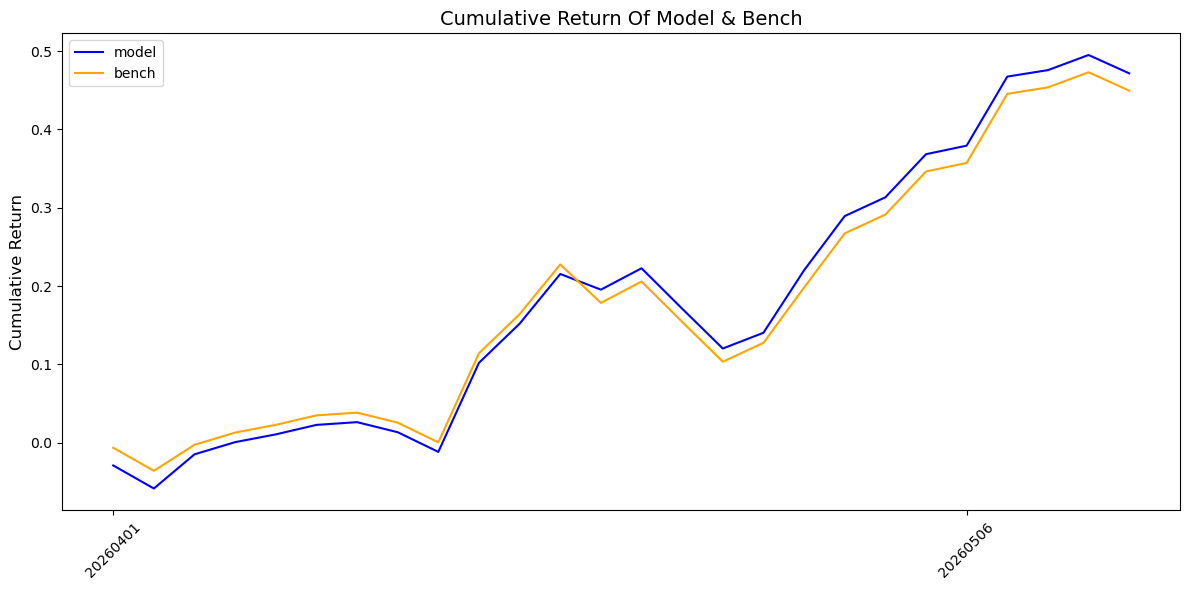

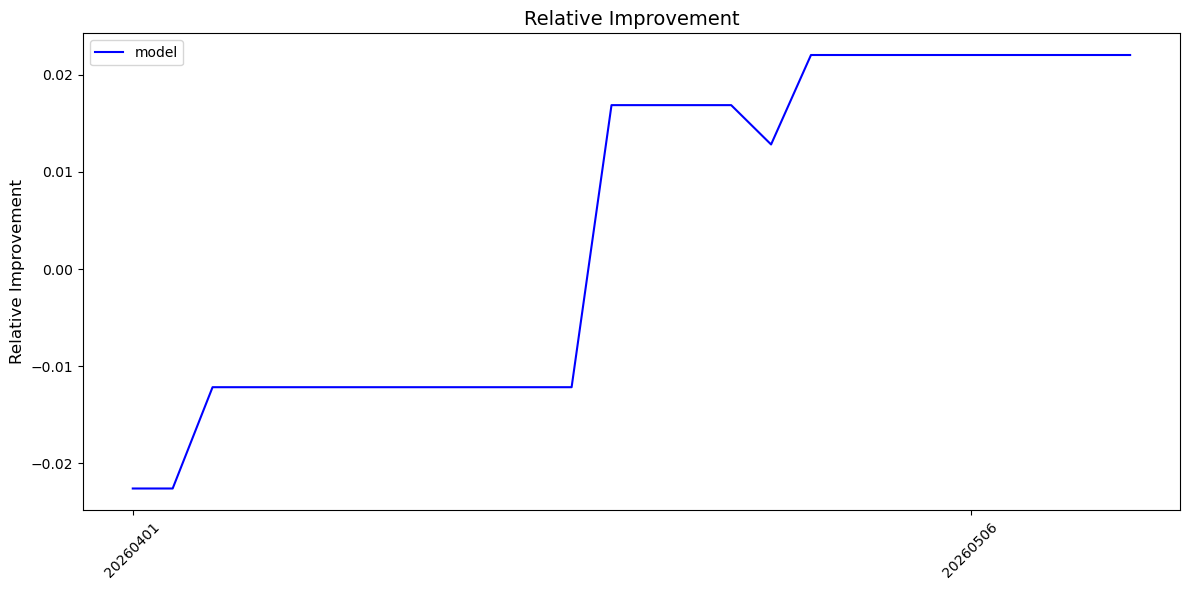

In [16]:
# 单模型效果评估（完整季度输出）
# 注意：当前 bench = 模型自身，集成评估无实际意义，待有真实 bench 后替换 bench1~4 即可
print("---单一模型评估---")
ret1, ic1 = engine.get_ret_ic(model_score, params.ret_data, params.liquid_data,
                              start=start, end=end, money=MONEY)
print_quarterly_metrics(ret1, ic1)
score1_metrics = engine.get_metrics(ret1, ic1)
print_metrics(score1_metrics)

# TODO: 有真实bench后，取消下面注释并替换 bench1~4
print("---该模型与现有集成模型的相关性---")
corr_with_bench = model_score.reindex(
    columns=bench_all.columns, index=bench_all.index
).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")

print("---模型集成评估---")
bench_new = engine.ensemble_scores(bench1, bench2, bench3, bench4, model_score)
print(f'加入当前模型后的多样性熵：{bench_new.groupby("date").apply(engine.diversity_entropy).mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())

bench_new_score = bench_new.mean(axis=1).unstack()
ret_new, ic_new = engine.get_ret_ic(bench_new_score, params.ret_data, params.liquid_data,
                                    start=start, end=end, money=MONEY)
print_quarterly_metrics(ret_new, ic_new)
bench_new_metrics = engine.get_metrics(ret_new, ic_new)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new_score, bench_all, params.ret_data, params.liquid_data,
           start=start, end=end, money=MONEY)

# 通用个人策略 vs Top 500 机构策略
# 自定义买入数量 + 涨停板过滤（涨幅>=9.5%不能买入）
# 使用 run_individual_strategy() 函数，修改 TOP_N 和 EXCLUDE_LIMIT_UP 即可


===== 多策略对比 =====
策略                                      年化收益     夏普比率       季均收益
-----------------------------------------------------------------
Top 500 (机构, 流动性约束)                   295.19%   4.2988     1.1714%
Top 1 (个人, 不过滤涨停)                     649.33%   7.4688     2.5767%
Top 3 (个人, 不过滤涨停)                     531.23%  10.1088     2.1080%
Top 5 (个人, 不过滤涨停)                     411.37%   9.2215     1.6324%
Top 10 (个人, 不过滤涨停)                    374.21%   9.0495     1.4850%
Top 20 (个人, 不过滤涨停)                    292.32%   7.6528     1.1600%


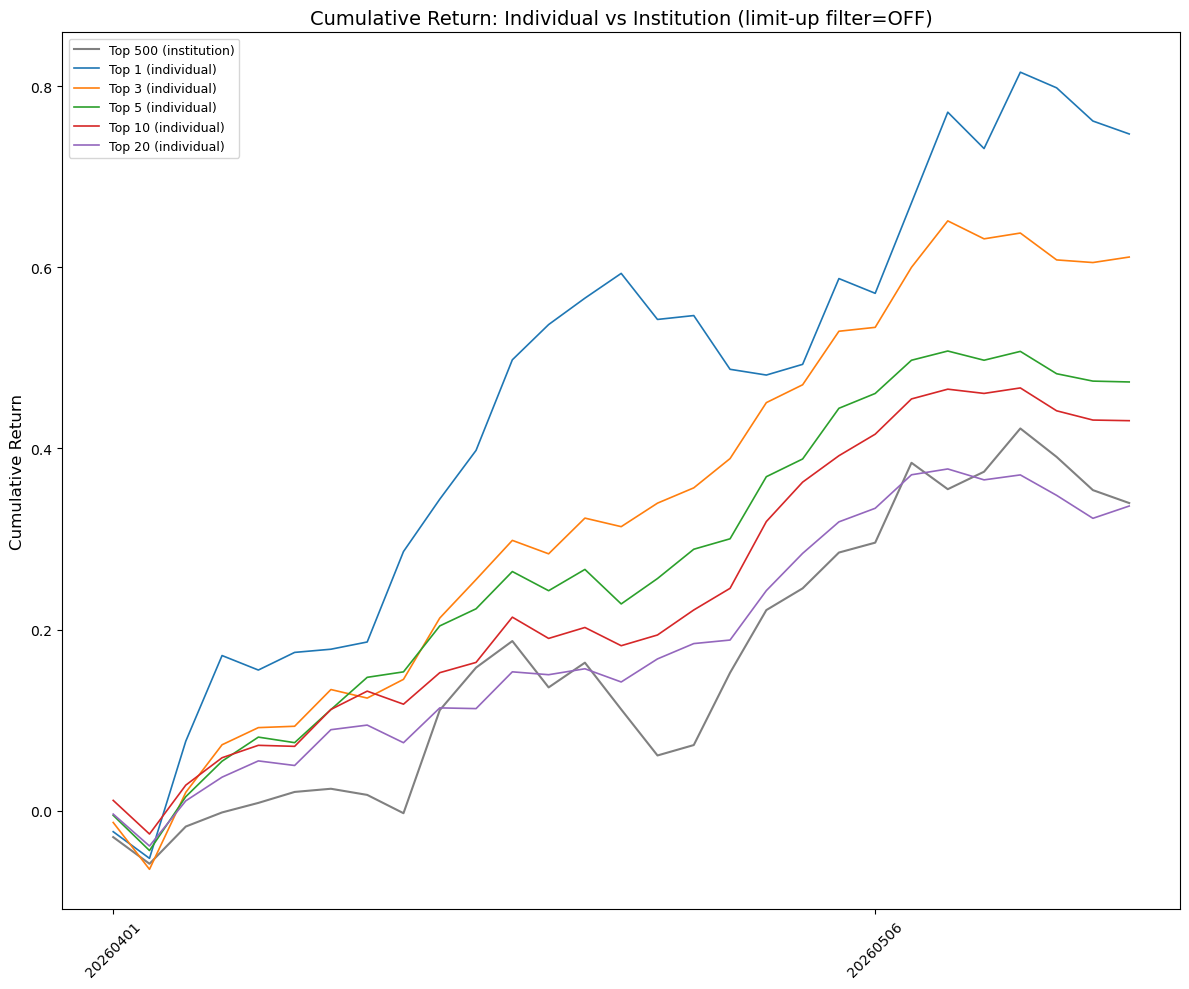

In [17]:
# ============================================================
# 通用个人策略：自定义买入数量 + 涨停板过滤
# 用法：修改顶部配置区的 TOP_N 和 EXCLUDE_LIMIT_UP，然后运行本单元格
# ============================================================

# Top 500 机构策略（用于对比）
top500_ret, _ = engine.get_ret_ic(model_score, params.ret_data, params.liquid_data,
                                  start=start, end=end, money=MONEY)
top500_ret = top500_ret / 100


# ---- 辅助函数 ----
def _print_strategy(label, ret_series):
    ann = ret_series.mean() * 252 * 100
    sharpe = (ret_series.mean() / ret_series.std() * np.sqrt(252)
              if ret_series.std() > 0 else 0)
    q_avg = ret_series.groupby(
        pd.to_datetime(ret_series.index).to_period('Q')
    ).mean().mean() * 100
    print(f"{label:<35} {ann:>8.2f}% {sharpe:>8.4f} {q_avg:>10.4f}%")


# ---- 多策略对比 ----
print("\n===== 多策略对比 =====")
print(f"{'策略':<35} {'年化收益':>8} {'夏普比率':>8} {'季均收益':>10}")
print("-" * 65)
_print_strategy("Top 500 (机构, 流动性约束)", top500_ret)

for n in [1, 3, 5, 10, 20]:
    r, s = engine.run_individual_strategy(model_score, params.ret_data, top_n=n,
                                          exclude_limit_up=EXCLUDE_LIMIT_UP,
                                          start=start, end=end)
    _print_strategy(f"Top {n} (个人, 不过滤涨停)", r)


# ---- 绘图对比 ----
dates = top500_ret.index.tolist()
seen_months = set()
month_ticks, month_labels = [], []
for i, d in enumerate(dates):
    month = d[:6]
    if month not in seen_months:
        seen_months.add(month)
        month_ticks.append(i)
        month_labels.append(d)

fig, axes = plt.subplots(1, 1, figsize=(12, 10))

axes.plot(dates, top500_ret.cumsum(), label='Top 500 (institution)',
          color='gray', linewidth=1.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, n in enumerate([1, 3, 5, 10, 20]):
    r, _ = engine.run_individual_strategy(model_score, params.ret_data, top_n=n,
                                          exclude_limit_up=EXCLUDE_LIMIT_UP,
                                          start=start, end=end)
    axes.plot(dates, r.cumsum(), label=f'Top {n} (individual)',
              color=colors[i], linewidth=1.2)
axes.set_title(
    f'Cumulative Return: Individual vs Institution '
    f'(limit-up filter={"ON" if EXCLUDE_LIMIT_UP else "OFF"})',
    fontsize=14
)
axes.set_ylabel('Cumulative Return', fontsize=12)
axes.set_xticks(month_ticks)
axes.set_xticklabels(month_labels, rotation=45)
axes.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 预测补充 & 最新推荐
自动检测 factor 数据中超出 model_res 覆盖范围的日期，使用最优模型进行预测，并展示最新打分结果与投资建议。

In [18]:
# ============================================================
# 1. 自动预测：补充 model_res 未覆盖的最新日期
# ============================================================

new_scores = engine.predict_missing_dates(model_score, season=SEASON)

if new_scores is not None:
    model_score_extended = pd.concat([model_score, new_scores], axis=0).sort_index()
    print(f"合并完成：原始 {len(model_score)} 天 + 新增 {len(new_scores)} 天 = {len(model_score_extended)} 天")
    print(f"新增日期: {list(new_scores.index)}")

    # 落盘到 model_pred
    basic_name = 'nn--fac20260517--label--dropout0.2'
    pred_dir = rf'{root_path}/model_pred/{basic_name}/{SEASON}'
    engine.save_predictions(new_scores, pred_dir)
else:
    model_score_extended = model_score.copy()
    print("无新增日期，使用原始 model_score。")


[预测] 已排除 2 个非交易日: ['20260516', '20260517']
[预测] 发现 2 个未覆盖交易日: ['20260518', '20260519']
[预测] 使用 4 个 fold 进行预测
[预测]   [fold1] epoch=12-val_wei=0.4110.ckpt (val_wei=0.4110)
[预测]   [fold2] epoch=5-val_wei=0.5532.ckpt (val_wei=0.5532)
[预测]   [fold3] epoch=55-val_wei=0.9790.ckpt (val_wei=0.9790)
[预测]   [fold4] epoch=27-val_wei=1.3644.ckpt (val_wei=1.3644)
[预测]   [20260518] 完成, 2542 只股票
[预测]   [20260519] 完成, 2542 只股票
[预测] 完成，共 2 天数据。
合并完成：原始 29 天 + 新增 2 天 = 31 天
新增日期: ['20260518', '20260519']
[保存] 20260518 -> /root/shared-nvme/lingqiData/Model/V2/model_pred/nn--fac20260517--label--dropout0.2/2026q2/20260518.pkl
[保存] 20260519 -> /root/shared-nvme/lingqiData/Model/V2/model_pred/nn--fac20260517--label--dropout0.2/2026q2/20260519.pkl


In [19]:
# ============================================================
# 1.5 历史验证：预测 model_test 最后 3 天，与已有结果对比一致性
# ============================================================

hist_dates = sorted(model_score.index)[-3:]
print(f"历史验证日期: {hist_dates}")

hist_scores = engine.predict_dates(hist_dates, season=SEASON)

if hist_scores is not None:
    # 落盘
    basic_name = 'nn--fac20260517--label--dropout0.2'
    hist_dir = rf'{root_path}/model_pred/{basic_name}/{SEASON}'
    engine.save_predictions(hist_scores, hist_dir)

    print("\n--- 与 model_test 一致性验证 ---")
    for date in hist_dates:
        if date in hist_scores.index and date in model_score.index:
            old = model_score.loc[date]
            new = hist_scores.loc[date]
            common = old.index.intersection(new.index)
            if len(common) > 0:
                corr = old[common].corr(new[common])
                print(f"  {date}: corr={corr:.6f}, 共同股票数={len(common)}")
            else:
                print(f"  {date}: 无共同股票")


历史验证日期: ['20260513', '20260514', '20260515']
[预测] 使用 4 个 fold 进行预测
[预测]   [fold1] epoch=12-val_wei=0.4110.ckpt (val_wei=0.4110)
[预测]   [fold2] epoch=5-val_wei=0.5532.ckpt (val_wei=0.5532)
[预测]   [fold3] epoch=55-val_wei=0.9790.ckpt (val_wei=0.9790)
[预测]   [fold4] epoch=27-val_wei=1.3644.ckpt (val_wei=1.3644)
[预测]   [20260513] 完成, 2542 只股票
[预测]   [20260514] 完成, 2542 只股票
[预测]   [20260515] 完成, 2542 只股票
[预测] 完成，共 3 天数据。
[保存] 20260513 -> /root/shared-nvme/lingqiData/Model/V2/model_pred/nn--fac20260517--label--dropout0.2/2026q2/20260513.pkl
[保存] 20260514 -> /root/shared-nvme/lingqiData/Model/V2/model_pred/nn--fac20260517--label--dropout0.2/2026q2/20260514.pkl
[保存] 20260515 -> /root/shared-nvme/lingqiData/Model/V2/model_pred/nn--fac20260517--label--dropout0.2/2026q2/20260515.pkl

--- 与 model_test 一致性验证 ---
  20260513: corr=1.000000, 共同股票数=2542
  20260514: corr=1.000000, 共同股票数=2542
  20260515: corr=1.000000, 共同股票数=2542


In [20]:
# ============================================================
# 2. 最新推荐展示：股票名称映射、Top 打分、投资建议
# ============================================================

# --- 股票代码 → 名称映射 ---
stock_info = pd.read_parquet('/root/shared-nvme/lingqiData/data/list.parquet')
stock_info = stock_info[stock_info['list_status'] == 'L']
code_to_name = {
    re.sub(r'\.(SZ|SH|BJ)$', '', row['stock_code']): row['name']
    for _, row in stock_info.iterrows()
}

# --- 交易日历 ---
cal = pd.read_parquet('/root/shared-nvme/lingqiData/data/calendar.parquet')
cal = cal[cal['is_open'] == 1]
_trade_dates = sorted(cal['date'].astype(str).str.replace('-', '').tolist())


def get_nth_next_trade_date(date_str, n=1):
    """获取 date_str 之后第 n 个交易日"""
    try:
        idx = _trade_dates.index(date_str)
        if idx + n < len(_trade_dates):
            return _trade_dates[idx + n]
    except (ValueError, IndexError):
        pass
    return None


def fmt_date(date_str):
    if date_str is None:
        return "待定（交易日历未覆盖）"
    return f"{date_str[:4]}年{int(date_str[4:6])}月{int(date_str[6:8])}日"


# ============================================================
# 数据当前日期 & 预测日期推算
# ============================================================

# 原始 model_res 的最新日期（有真实 label 的最后一天）
last_label_date = model_score.index.max()

# 因子数据的最新日期（即这一批数据的"当前日期"）
latest_factor_date = model_score_extended.index.max()

# 本次新增的预测日期（model_res 未覆盖、通过 prediction 补充的日期）
predicted_dates = sorted(set(model_score_extended.index) - set(model_score.index))
predicted_dates.sort()


# ============================================================
# 展示预测日期的 Top 推荐
# ============================================================
print()
print("=" * 72)
print("                    最新模型打分 Top 推荐")
print("=" * 72)

for date in predicted_dates:
    scores = model_score_extended.loc[date].sort_values(ascending=False)
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    print(f"\n{'─' * 60}")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    top_n = min(10, len(scores))
    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
    print(f"  {'-' * 37}")
    for rank, (code, score) in enumerate(scores.head(top_n).items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}")


                    最新模型打分 Top 推荐

────────────────────────────────────────────────────────────
  当前日期：2026年5月19日 收盘
  模型预测1日收益率：2026年5月19日 买入 → 2026年5月20日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    002903    宇环数控        +  11.5810
  2    002217    合力泰         +  11.5613
  3    603315    福鞍股份        +  10.7724
  4    002213    大为股份        +   9.7253
  5    002663    普邦股份        +   9.4439
  6    002757    南兴股份        +   9.4026
  7    603660    苏州科达        +   9.0088
  8    002655    共达电声        +   8.6787
  9    000066    中国长城        +   8.5885
  10   002290    禾盛新材        +   8.5269

────────────────────────────────────────────────────────────
  当前日期：2026年5月19日 收盘
  模型预测1日收益率：2026年5月20日 买入 → 2026年5月21日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    002421    达实智能        + 

# 自选股排序
从 `/root/shared-nvme/lingqiData/MyCode.txt` 读取自选股列表，展示全部自选股在最新预测日期上的打分排名。

In [23]:
# ============================================================
# 自选股排序：读取 MyCode.txt，展示全部自选股打分
# ============================================================

watchlist = np.loadtxt(watchlist_path)
watchlist_codes = [str(int(code)).zfill(6) for code in watchlist]

for date in predicted_dates:
    scores = model_score_extended.loc[date]
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    watch_scores = scores.reindex(watchlist_codes).dropna().sort_values(ascending=False)
    missing = [c for c in watchlist_codes if c not in scores.index]

    # 全市场排名（1 = 最优）
    all_ranks = scores.rank(ascending=False).astype(int)
    total = len(scores)

    print(f"\n{'─' * 60}")
    print(f"  自选股打分排序")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}  {'总排名':>8}  {'百分位':>10}")
    print(f"  {'─' * 55}")
    for rank, (code, score) in enumerate(watch_scores.items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        total_rank = all_ranks.get(code, '-')
        pct = f'{total_rank / total * 100:.2f}%' if total_rank != '-' else '-'
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}  {str(total_rank):>8}/{total}  {pct:>10}")

    if missing:
        print(f"\n  以下自选股无模型打分（可能已退市或不在股票池中）：{missing}")




────────────────────────────────────────────────────────────
  自选股打分排序
  当前日期：2026年5月19日 收盘
  模型预测1日收益率：2026年5月19日 买入 → 2026年5月20日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分       总排名         百分位
  ───────────────────────────────────────────────────────
  1    002466    天齐锂业        +   3.9969       132/2542       5.19%
  2    601988    中国银行        +   3.4894       195/2542       7.67%
  3    000725    京东方Ａ        +   1.2637       786/2542      30.92%
  4    600030    中信证券        +   0.4350      1148/2542      45.16%
  5    601398    工商银行        +   0.3785      1179/2542      46.38%
  6    000100    TCL科技       +   0.2994      1210/2542      47.60%
  7    601288    农业银行          -0.3845      1523/2542      59.91%
  8    601857    中国石油          -0.9920      1794/2542      70.57%
  9    002230    科大讯飞          -1.0705      1834/2542      72.15%
  10   000625    长安汽车          -1.6053      1998/2542      78.60%
  11   000651    

# 个股分数查询
输入日期和股票代码，查询该股票在当天的模型打分、全市场排名及百分位。

In [22]:
# ============================================================
# 个股分数查询：输入日期 + 股票代码，查询打分、排名、百分位
# 用法：修改 query_date 和 query_code，然后运行本单元格
# ============================================================

query_date = '20260515'   # <-- 修改为你要查询的日期 (YYYYMMDD)
query_code = '002466'     # <-- 修改为你要查询的股票代码 (6位数字)

scores_all = model_score_extended
code_name = code_to_name.get(query_code, '未知')

# --- 检查日期 ---
if query_date not in scores_all.index:
    avail = sorted(scores_all.index)
    print(f"日期 {query_date} 不在打分数据中。")
    print(f"可用日期范围：{avail[0]} ~ {avail[-1]}，共 {len(avail)} 个交易日。")
else:
    date_scores = scores_all.loc[query_date].dropna().sort_values(ascending=False)
    total = len(date_scores)

    if query_code not in date_scores.index:
        print(f"股票 {query_code}（{code_name}）在 {fmt_date(query_date)} 无打分数据（可能停牌/退市/未覆盖）。")
    else:
        score = date_scores[query_code]
        rank = date_scores.index.get_loc(query_code) + 1
        pct = rank / total * 100

        print(f"\n{'=' * 56}")
        print(f"  个股分数查询")
        print(f"{'=' * 56}")
        print(f"  日期      ：{fmt_date(query_date)}")
        print(f"  代码 / 名称：{query_code} / {code_name}")
        print(f"  模型打分  ：{score:+.4f}")
        print(f"  排名      ：{rank} / {total}")
        print(f"  百分位    ：Top {pct:.2f}%")
        print(f"{'=' * 56}")

        # --- 附近排名参考 ---
        margin = 3
        nearby = date_scores.iloc[max(0, rank - 1 - margin):min(total, rank + margin)]
        print(f"\n  附近排名参考：")
        print(f"  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
        print(f"  {'─' * 37}")
        for (c, s) in nearby.items():
            marker = '→' if c == query_code else ' '
            n = code_to_name.get(c, '未知')
            sign = '+' if s > 0 else ''
            print(f"  {marker} {date_scores.index.get_loc(c) + 1:<3}{c:<10}{n:<12}{sign}{s:>9.4f}")


  个股分数查询
  日期      ：2026年5月15日
  代码 / 名称：002466 / 天齐锂业
  模型打分  ：+4.8318
  排名      ：99 / 2542
  百分位    ：Top 3.89%

  附近排名参考：
  排名   代码        名称                  打分
  ─────────────────────────────────────
    96 603050    科林电气        +   4.8456
    97 603602    纵横通信        +   4.8390
    98 002383    合众思壮        +   4.8326
  → 99 002466    天齐锂业        +   4.8318
    100603121    华培动力        +   4.8078
    101603222    济民健康        +   4.7849
    102600303    曙光股份        +   4.7829
